In [1]:
import pandas as pd # For dataframes (tables)
import numpy as np # For numerical operations
import math
import matplotlib.pyplot as plt # For plots
import os # To import external python files
import sys# To import external python files

from pandas.plotting import scatter_matrix

# This a comment...


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
os.chdir('/content/drive/MyDrive/Projet MAIA 12 - Room Occupancy Estimation')

Load the dataset previously preprocessed. ...



In [12]:
df = pd.read_csv('Occupancy_Estimation.csv')

In [14]:
df.head(n=11)

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1
5,2017/12/22,10:52:14,25.00,24.81,24.56,25.44,121,34,54,40,0.13,0.06,0.06,0.07,390,0.165385,0,0,1
6,2017/12/22,10:52:45,25.00,24.75,24.56,25.44,120,34,54,40,1.39,0.32,0.43,0.06,390,0.076923,1,0,1
7,2017/12/22,10:53:15,25.00,24.81,24.56,25.44,121,34,54,41,0.09,0.06,0.09,0.05,390,-0.011538,0,0,1
8,2017/12/22,10:53:46,25.00,24.81,24.56,25.50,122,35,56,43,0.09,0.05,0.06,0.13,390,-0.100000,0,0,1
9,2017/12/22,10:54:17,25.00,24.81,24.56,25.50,101,34,57,43,3.84,0.64,0.48,0.39,390,-0.188462,1,1,1


In [15]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

We first check the meaning from the repository [Requet dataset](https://github.com/Wimnet/RequetDataSet).

Check the possbile values that a certain feature can take

In [16]:
print ("Values of Room_Occupancy_Count: ",  df['Room_Occupancy_Count'].unique() )
print ("Values of S5_CO2: ",  df['S5_CO2'].unique() )

Values of Room_Occupancy_Count:  [1 2 3 0]
Values of S5_CO2:  [ 390  395  400  405  410  415  420  425  430  435  445  440  450  455
  460  475  480  485  490  500  510  515  520  525  530  540  545  550
  555  560  565  570  580  585  590  600  595  605  610  615  620  625
  630  635  640  645  650  655  660  665  670  680  675  685  690  695
  700  810  815  820  835  840  845  850  855  860  865  875  880  885
  870  890  895  900  905  910  915  920  925  930  935  940  945  955
  960  965  970  975  950  830  805  800  795  785  775  770  765  760
  755  750  740  730  720  715  710  705  575  725  735  745  790  825
  980  985  995 1000 1010 1015 1025 1030 1040 1035 1045 1050 1055 1060
 1065 1070 1075 1080 1085 1090 1095 1105 1110 1100 1115 1120 1130 1135
 1145 1150 1160 1165 1155 1170 1180 1185 1195 1200 1205 1210 1190 1215
 1225 1220 1235 1240 1245 1250 1260 1265 1270 1255 1230 1175 1140 1125
 1020 1005  990  780  535  505  495  470  465  385  380  375  370  365
  360  355  350

# Basic statistics

How many samples and columns are present in our dataset?

In [17]:
df.shape

(10129, 19)

In [18]:
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


## 1st and 2nd order statistics

If we have $m$ samples
Statistics of the $j$-th feature:

|<span> | | |
|---------------|-------|:--|
| Mean| $
    \mu_j \triangleq $  $    \frac{1}{m} \sum_{i=1}^m
        x_j^{(i)}
$ |
|Variance| $
    \text{Var}_j \triangleq$      $\frac{1}{m-1} \sum_{i=1}^m
        \left( x_j^{(i)} - \mu_j \right)^2
$|
|Standard deviation|$
\sigma_j \triangleq $ | $ \sqrt{\text{Var}_j}
$|


Note: Why $m-1$? See [Wikipedia](https://en.wikipedia.org/wiki/Variance#Sample_variance) (Not important to retain).



## Boxplot

It represents minimum, percentiles (25%,50%,75%) and maximum.

<Axes: >

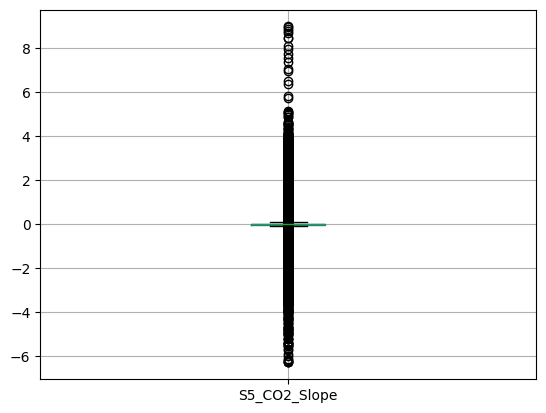

In [23]:
df.boxplot(column=['S5_CO2_Slope'])

<Axes: >

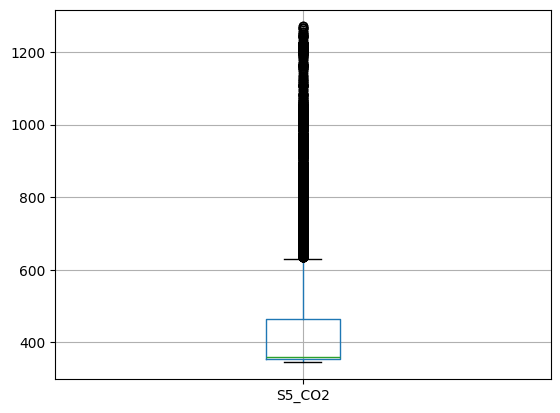

In [21]:
df.boxplot(column=['S5_CO2'])

#### Outliers

First compute the Inter-Quartile range (range of the box):
    \begin{align}
    \text{IQR} \triangleq p_{75\%} - p_{25\%}
    \end{align}
    

Upper __whisker__ : $\min(p_{75\%} + 1.5 \cdot \text{IQR}, \text{max_value} )$

Lower __whisker__ : $\max(p_{25\%} - 1.5 \cdot \text{IQR}, \text{min_value} )$

All points outside are considered **outliers**

We can print the box plots of many columns

<Axes: >

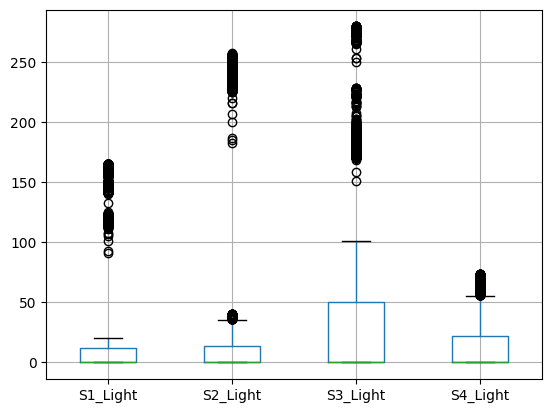

In [24]:
df.boxplot(column=['S1_Light', 'S2_Light', 'S3_Light' , 'S4_Light' ])

<Axes: >

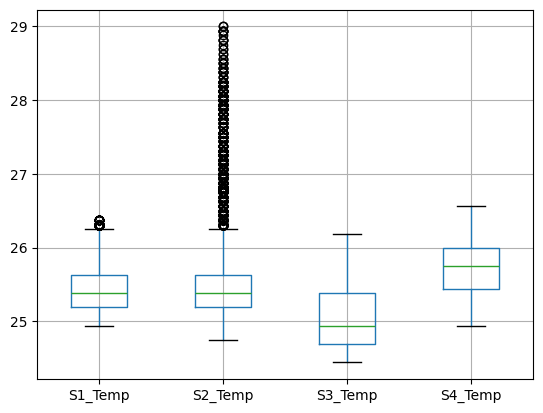

In [27]:
df.boxplot(column=['S1_Temp', 'S2_Temp', 'S3_Temp' , 'S4_Temp' ])

<Axes: >

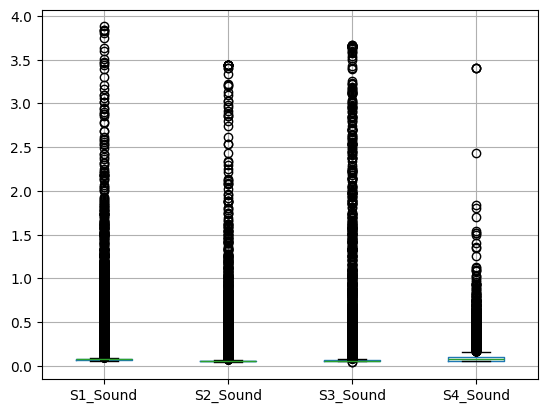

In [28]:
df.boxplot(column=['S1_Sound', 'S2_Sound', 'S3_Sound' , 'S4_Sound' ])

## Histogram

We can plot the histogram of all the features

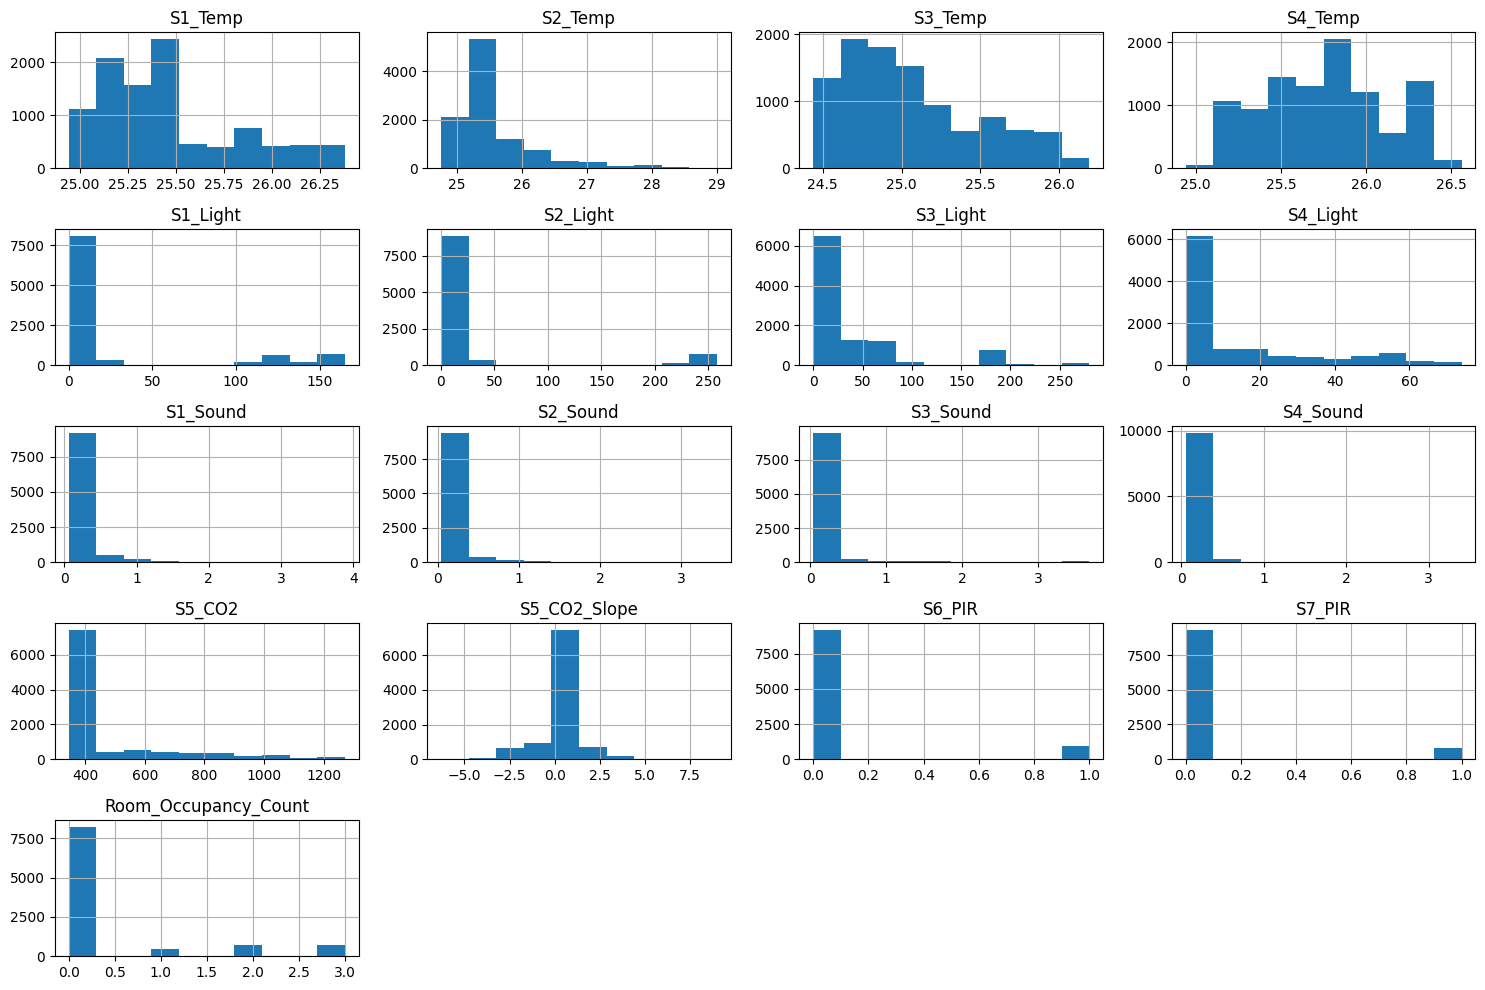

In [26]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10))  # Adjust width and height as needed
plt.tight_layout()         # Optional: avoids overlap between plots
plt.show()

#### Group by
How does the distribution of a feature changes with the quality?

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

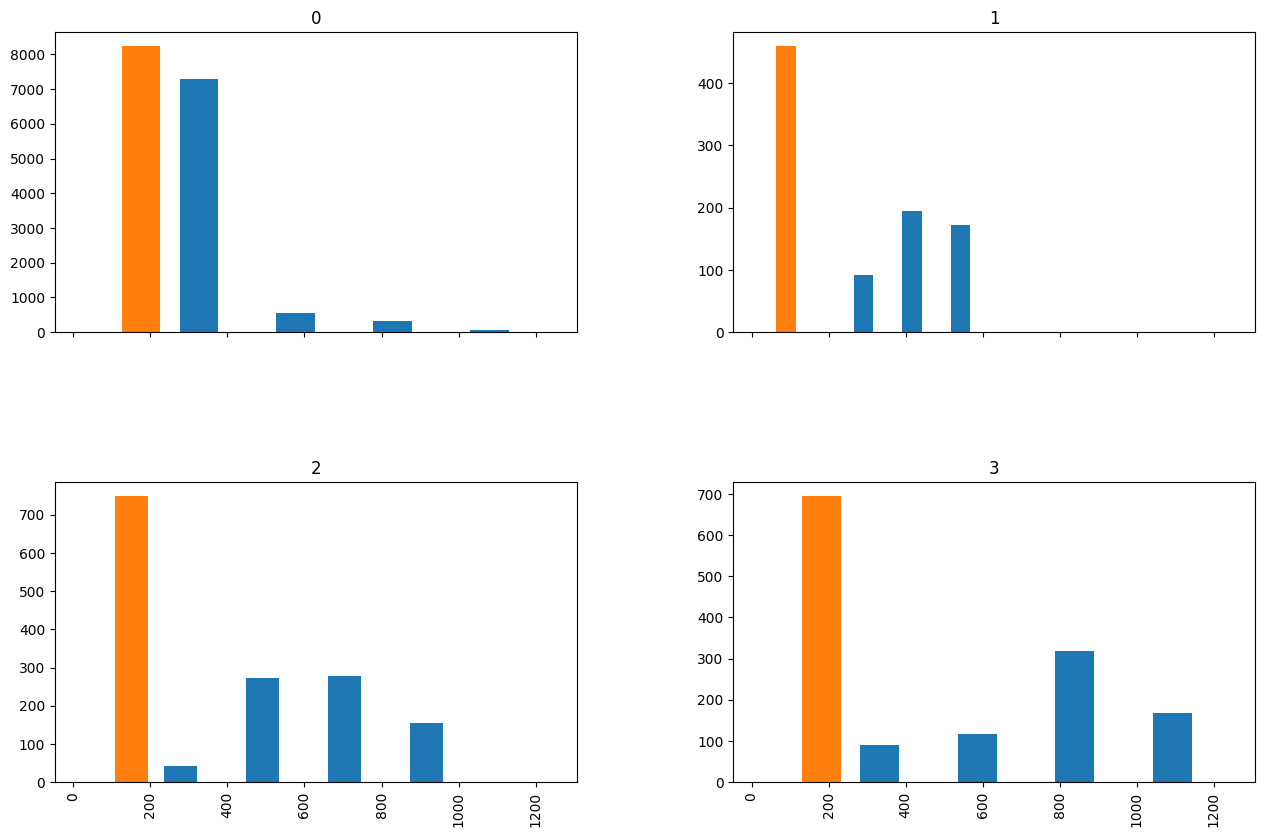

In [58]:
# sharex imposes all the plots to have the same x range
# (otherwise visual comparison is different).
df[['S5_CO2', 'Room_Occupancy_Count']].hist(figsize=(15,10), by='Room_Occupancy_Count',
                                    sharex=True, bins = 5)

As expected, the higher the  ```Room Occupancy Count``` the more the ```S5 CO2```concentrate toward higher values.

# Correlations

How do feature relate each other?

Use `scatter_matrix`. If the dataset is big, it would take too long. Let just selects few columns. For instance, the overall metrics (not the connection-wise metrics)

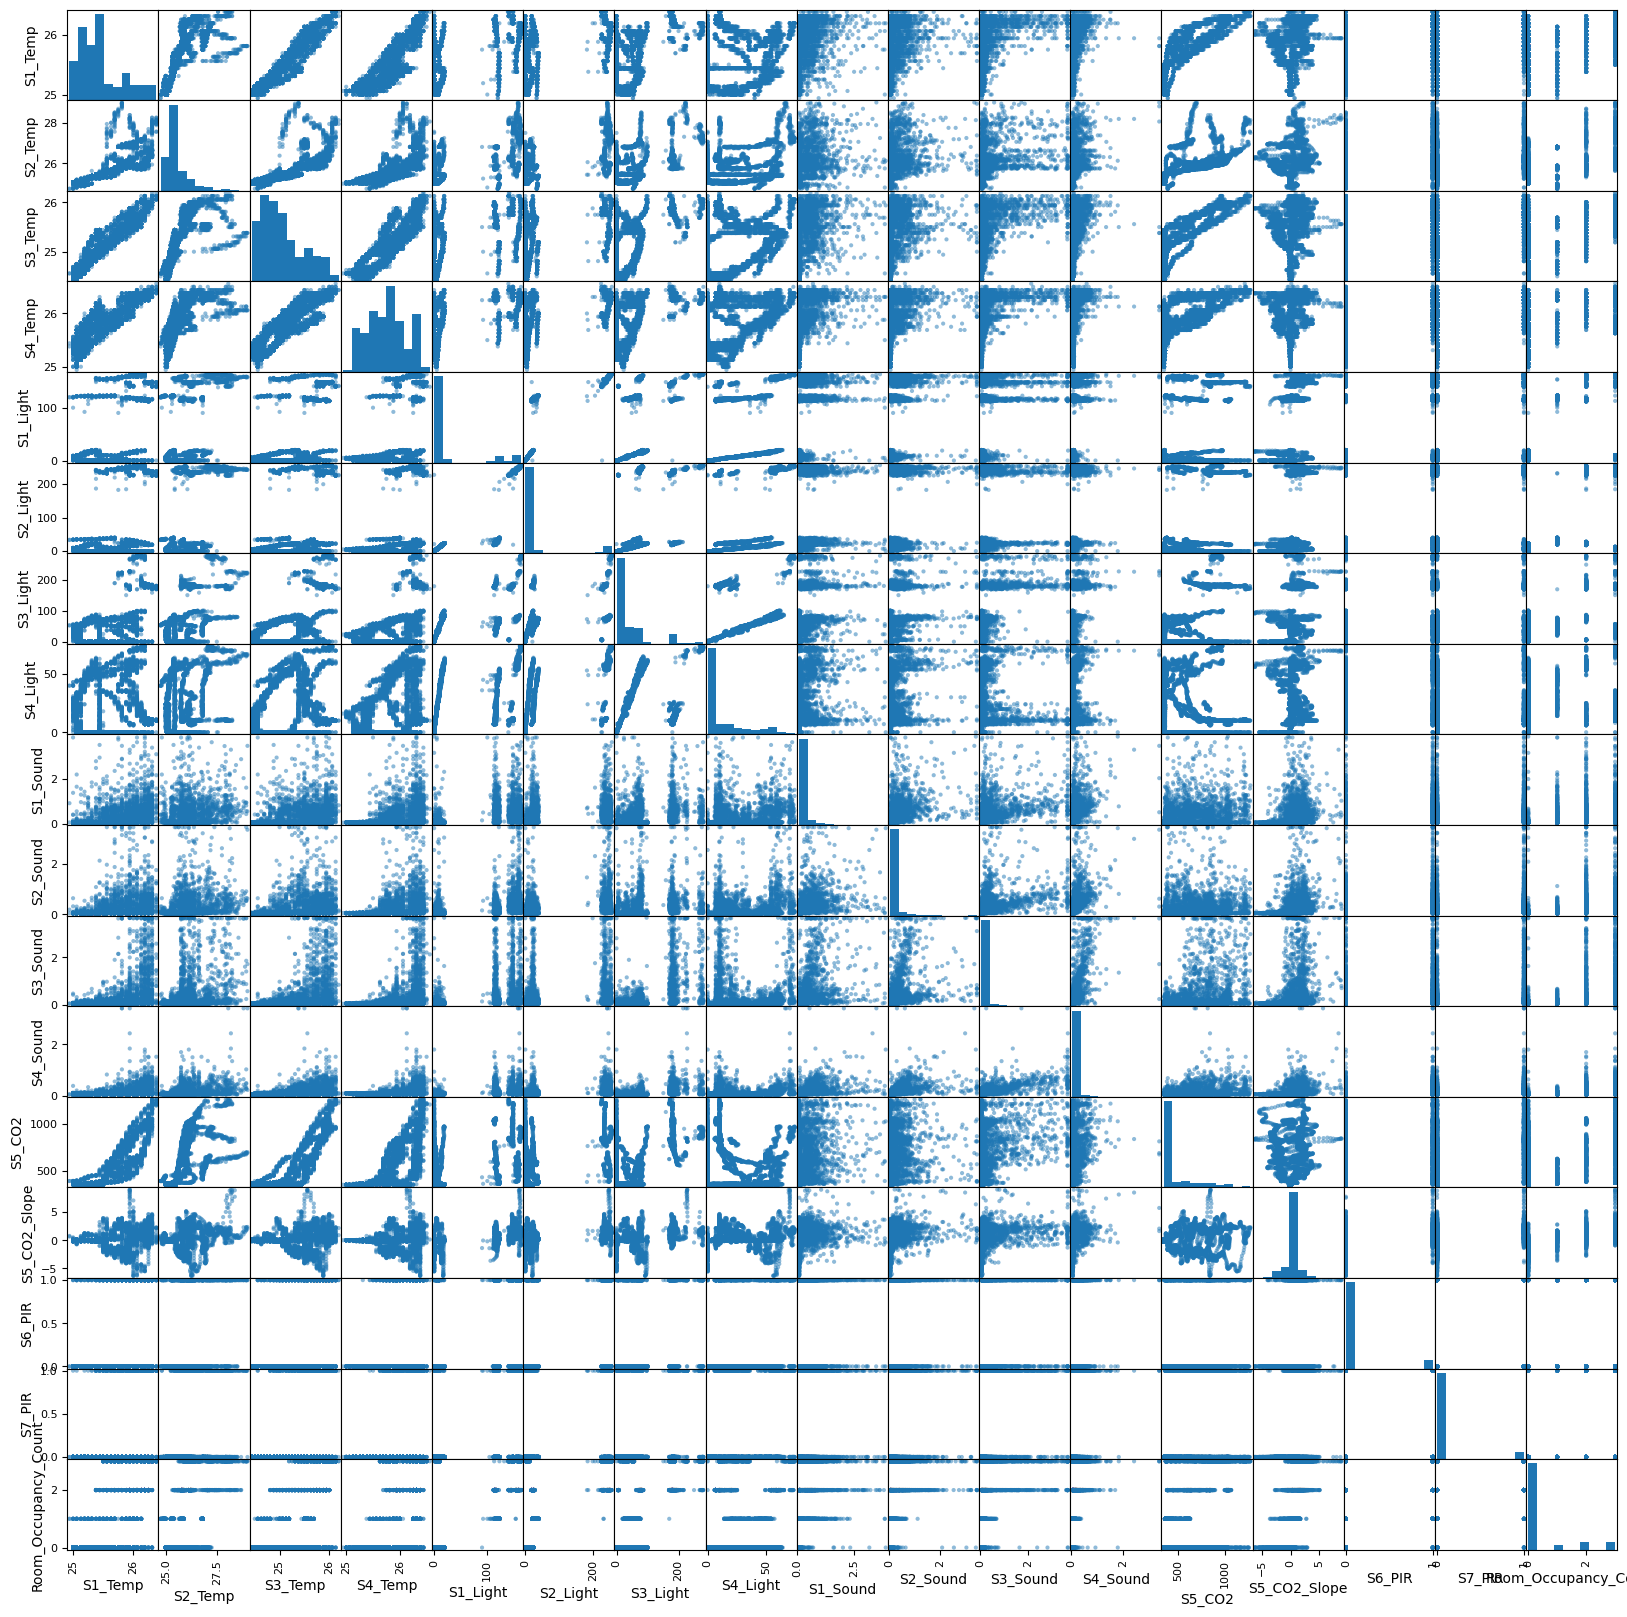

In [37]:
sm = scatter_matrix(df,figsize=(20,20))

plt.show()

Trivial correlations:
* PacketsSent vs. BytesSent
* PacketsReceived vs. BytesReceived
* BufferHealth vs. BufferProgress

Interesting correlations:
* PacketsReceived vs. PacketsSent
*  BufferHealth and BufferProgress are linearly dependent.
    * While we reproduce the video, our ahead-buffer fills more and more

* **BufferProgress**: (fraction of video downloaded into the browser buffer)
* **BufferHealth**: (how many "future seconds of video" we already have in the buffer)



Unfortunately, `label` is not plotted, since it is not numeric. Let us transform it in numerical form.



## Pearson's correlation

It is a way to mathematically express correlation between two features $j,j'$. For each sample, we compute:
    \begin{align}
    \left( x_j^{(i)} - \mu_j \right) \cdot \left( x_{j'}^{(i)} - \mu_{j'} \right)
    \end{align}
    
Averaging across all samples, we obtain the **covariance between features** $j,j'$ ([wikipedia](https://en.wikipedia.org/wiki/Covariance#Calculating_the_sample_covariance))
        \begin{align}
        \text{Cov}(j,j') =
    \frac{1}{m-1}\sum_{i=1}^m \left( x_j^{(i)} - \mu_j \right) \cdot \left( x_{j'}^{(i)} - \mu_{j'} \right)
    \end{align}


We divide by the standard deviations to normalize, and we obtain the **Person's correlation coefficient**
    \begin{align}
    \rho_{j,j'} = \frac{\text{Cov}(j,j')}{\sigma_j\cdot \sigma_{j'}}
    \end{align}

It can be shown that
    $$ -1 \le \rho_{j,j'} \le 1
    $$


Examples of different values of Pearson correlation (in the picture it is indicated as $r$ instead of $\rho$), between $x$ and $y$ values. Note that when $\rho=1$ or $\rho=-1$, there is linear dependence between $x$ and $y$. We can say that Pearson's correlation measures how much much there is linear dependence between features.

<img src=https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/01.introduction/img/persons.png width=600>

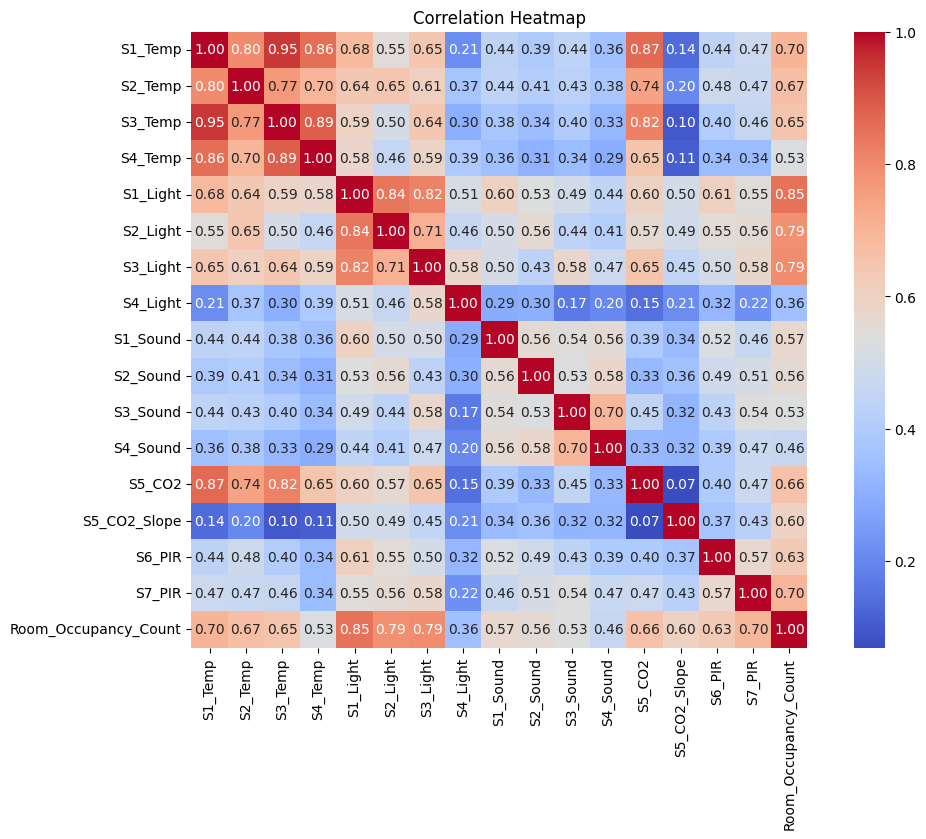

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  # Adjust size as needed

# Draw the heatmap
sns.heatmap(df.iloc[:, 2:].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)

plt.title("Correlation Heatmap")
plt.show()


In [46]:
! wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/visualization.py
import visualization

--2025-05-06 21:53:53--  https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/visualization.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13023 (13K) [text/plain]
Saving to: ‘visualization.py’

visualization.py    100%[===================>]  12.72K  --.-KB/s    in 0.005s  

2025-05-06 21:53:53 (2.46 MB/s) - ‘visualization.py’ saved [13023/13023]



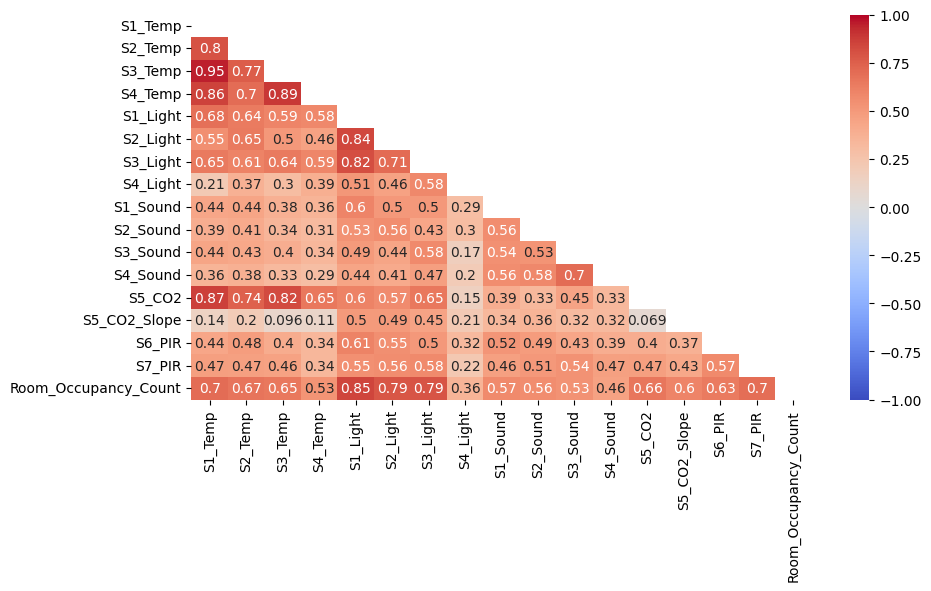

In [47]:
visualization.plot_corr(df.iloc[: , 2:], width=10, height=5,
                        print_value=True)

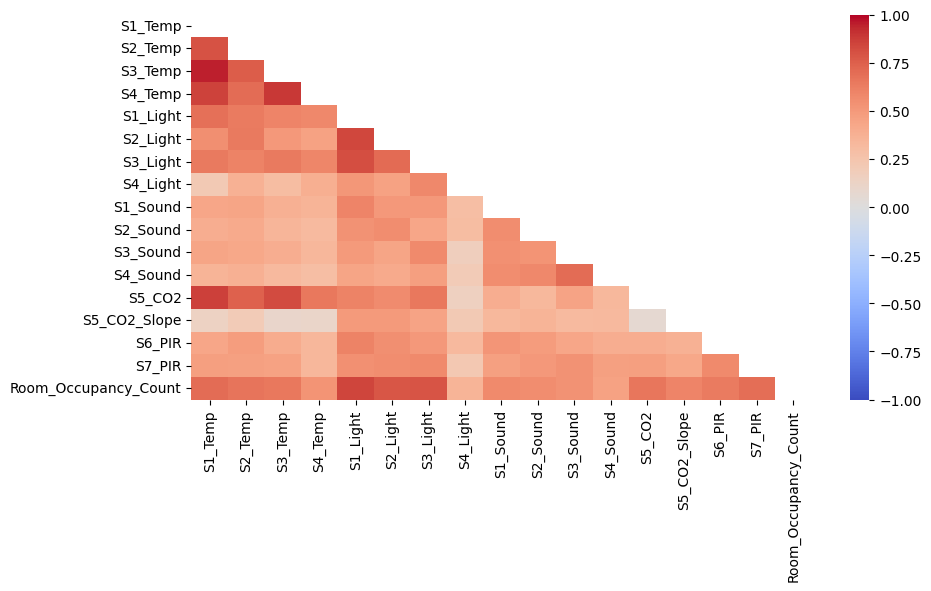

In [49]:
visualization.plot_corr(df.iloc[: , 2:], width=10, height=5,
                        print_value=False)

#### Feature importance (based on Person's correlation)

What are the most correlated features to `Room Occupancy`?

In [57]:
# From the course library
! wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/feature_engineering.py
import feature_engineering


--2025-05-06 22:00:22--  https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/feature_engineering.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2593 (2.5K) [text/plain]
Saving to: ‘feature_engineering.py.1’

feature_engineering 100%[===================>]   2.53K  --.-KB/s    in 0.003s  

2025-05-06 22:00:22 (923 KB/s) - ‘feature_engineering.py.1’ saved [2593/2593]



In [56]:
features_corr = \
        feature_engineering.get_features_correlated_to_target(
                df.iloc[ : ,2:], target_feature='Room_Occupancy_Count')

features_corr

,Room_Occupancy_Count
Room_Occupancy_Count,1.00
S1_Light,0.85
S3_Light,0.79
S2_Light,0.79
S1_Temp,0.70
S7_PIR,0.70
S2_Temp,0.67
S5_CO2,0.66
S3_Temp,0.65
S6_PIR,0.63


# Transformation

Min- Max tries to get the values closer to mean. But when there are outliers in the data which are important and we don’t want to loose their impact ,we go with Z score normalization.

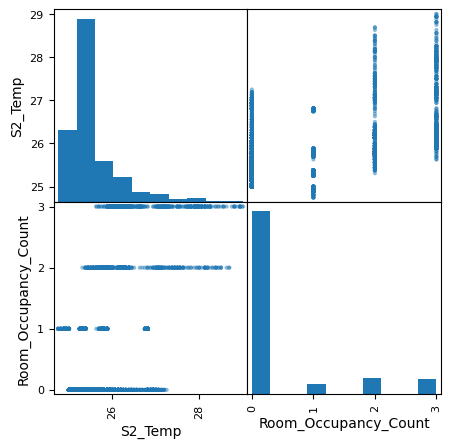

In [64]:
cols = ['S2_Temp','Room_Occupancy_Count']
sm = scatter_matrix(df[cols],
                   figsize=(5,5))

There are many samples crowded together around low values of `PacketsSent`. We would like to "zoom in" into those values to discern them.

In [65]:
df['S2_Temp_log'] = np.log(df['S2_Temp'])

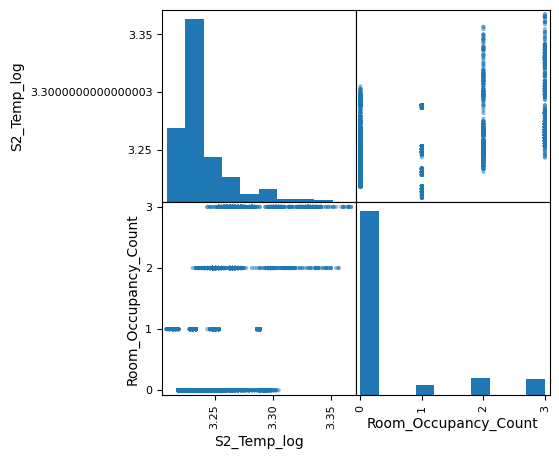

In [67]:
cols = ['S2_Temp_log','Room_Occupancy_Count']
sm = scatter_matrix(df[cols],
                   figsize=(5,5))

What changed:
* Values of KBytesReceived are better spread
* Looking at `label_num` vs. `KBytesReceived_log`, the values are less squashed down

This let correlation better emerge:

In [ ]:
corrmatrix = df_cleaned.corr()
print("Original correlation: ", corrmatrix['KBytesReceived']['label_num'],
     "; Correlation after transformation: ",
     corrmatrix['KBytesReceived_log']['label_num'])

Original correlation:  0.26444253489122005 ; Correlation after transformation:  0.3399134831774235


#### Transform multiple features at a time.

Let's check what are the features that would benefit from log-transformation

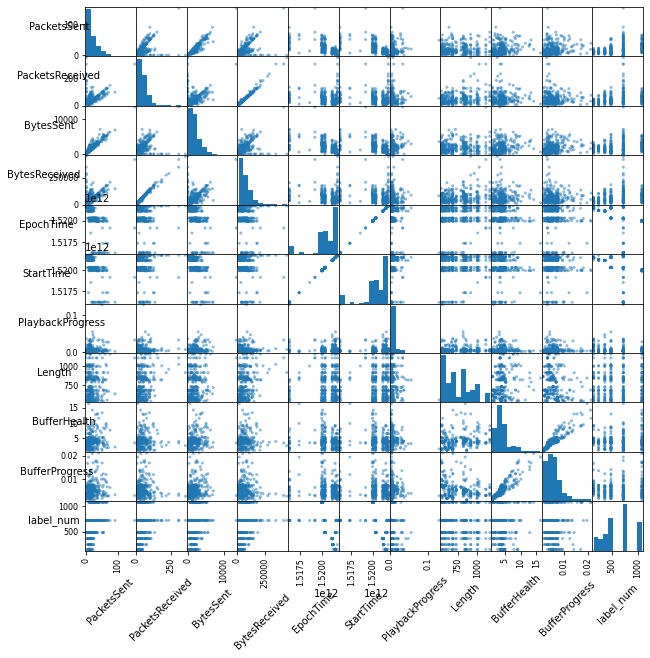

In [ ]:
sm = scatter_matrix(df_cleaned[columns_to_plot],
                   figsize=(10,10))
visualization.rotate_labels(sm)

plt.show()

They are
`PacketsSent`, `PacketsReceived`, `BytesSent`, `BytesReceived`,`BufferProgress`

In [ ]:
cols_to_transform = ['PacketsSent','PacketsReceived','BytesSent',
                  'BytesReceived','BufferProgress'];

cols_transformed = [s + "_log" for s in cols_to_transform]


df_cleaned[cols_transformed] = df_cleaned[cols_to_transform].transform(
                        func=lambda x : np.log(x))


/usr/local/lib/python3.6/dist-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**Attention**: The previous code returned an error! In effect log(0) is not defined. It's safer to use the transformation log(1+x)

In [ ]:
df_cleaned[cols_transformed] = df_cleaned[cols_to_transform].transform(
                        func=lambda x : np.log(1+x))

Let's print again the scattermatrix, replacing the original features with the transformed ones.

In [ ]:
columns_to_plot_after_transf = columns_to_plot.copy()
for feature in cols_to_transform:
    columns_to_plot_after_transf.remove(feature)

for feature in cols_transformed:
    columns_to_plot_after_transf.insert(0,feature)

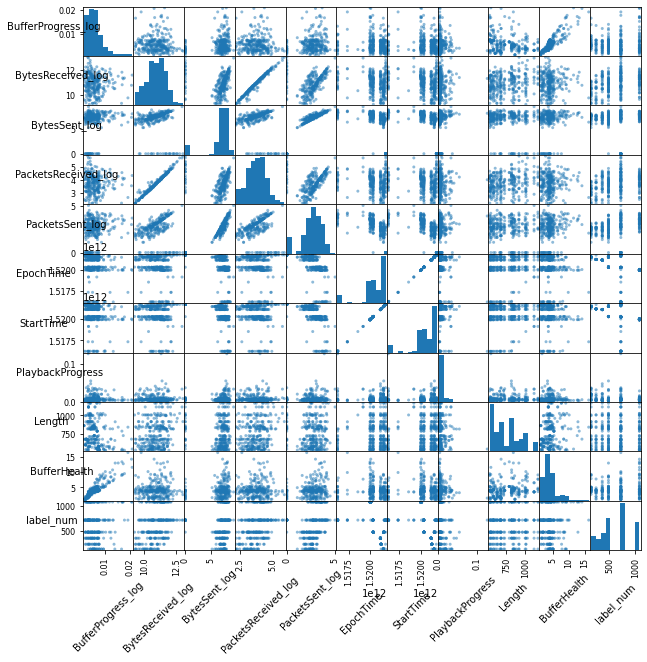

In [ ]:
sm = scatter_matrix(df_cleaned[columns_to_plot_after_transf],
                   figsize=(10,10))
visualization.rotate_labels(sm)

plt.show()

Let's check the most correlated features to `label_num`.

In [ ]:
feature_engineering.get_features_correlated_to_target(df_cleaned,
                                    target_feature='label_num').head(10)

label_num              1.00
StartTime             -0.41
EpochTime             -0.41
PacketsSent            0.38
PacketsSent0           0.36
PacketsReceived_log    0.34
KBytesReceived_log     0.34
BytesReceived_log      0.34
BytesSent0             0.30
PacketsSent_log        0.26
Name: label_num, dtype: float64

Before adding the transformed features, the most correlated features were

In [ ]:
features_corr.head(10)

label_num          1.00
StartTime         -0.41
EpochTime         -0.41
PacketsSent        0.38
PacketsSent0       0.36
BytesSent0         0.30
BytesReceived      0.26
KBytesReceived     0.26
PacketsReceived    0.25
BytesSent3        -0.23
Name: label_num, dtype: float64

We have unveiled more correlation in our data than it was before. It will be very useful to produce better models

### Which transformation?

There are many possible transformation you could use: see [here](https://medium.com/@TheDataGyan/day-8-data-transformation-skewness-normalization-and-much-more-4c144d370e55) and [here](https://medium.com/@ODSC/transforming-skewed-data-for-machine-learning-90e6cc364b0) . How would we choose?

* Visual inspection: you plot a variable vs. another and you apply some rules of thumb
   * If the values of a certain feature concentrate a lot on low values, apply `log`
   * In general, you can plot a feature vs. the target label, and if you recognize the shape of a well-known function, apply the corresponding transformation. The well-known functions in the following figure capture in a quite complete way the kinds of dependence you may find between a feature and the target. But, you have no limits, you can choose a non-linear transformation based on your fantasy, your intuition and your experience.

   ![alt text](https://miro.medium.com/max/1262/1*iEbD3x2S5KOiEI6ZOltp9w.png)

          Picture from randerson112358's [post](https://medium.com/@randerson112358/algorithm-analysis-time-complexity-simplified-cd39a81fec71) on medium.com

* Another alternative: you train a model capable of catpuring non-linearities (polynomial regression, linear network, random forests) and you let it transform the features automatically, for you.
* Use [Generalized Additive Models](https://youtu.be/f9Rj6SHPHUU) (outside our scope): they are able to choose the right transformation within a family of possible transformations.

# References

[1] Gutterman, C., Guo, K., Arora, S., Wang, X., Wu, L., Katz-Bassett, E., & Zussman, G. (2019). Requet: Real-time QoE detection for encrypted YouTube traffic. In ACM MMSys.

In [ ]:
df_cleaned.to_csv('df.A_2.csv',index = None, header=True)